# ML-Abschlussprojekt : Marktkampagne (Kundenanalyse und Marketingstrategie )

In [98]:
# Bibliotek importieren

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder, PolynomialFeatures

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans



import warnings
warnings.filterwarnings("ignore")


## Aufgabe 1: Explorative Datenanalyse und Verständnis des Datensatzes

1. **Datensatz einlesen und erste Übersicht:**

In [99]:
# 1) Datensatz laden
df = pd.read_csv('Marktkampagne.csv')
df.head()

,ID,Geburtsjahr,Bildungsniveau,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Datum_Kunde,Letzter_Kauf_Tage,Beschwerde,...,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne
0,5524,1967,Hochschulabschluss,Ledig,58138.0,0,0,04-09-2022,58,0,...,8,10,4,7,0,0,0,0,0,1
1,2174,1964,Hochschulabschluss,Ledig,46344.0,1,1,08-03-2024,38,0,...,1,1,2,5,0,0,0,0,0,0
2,4141,1975,Hochschulabschluss,Zusammenlebend,71613.0,0,0,21-08-2023,26,0,...,8,2,10,4,0,0,0,0,0,0
3,6182,1994,Hochschulabschluss,Zusammenlebend,26646.0,1,0,10-02-2024,26,0,...,2,0,4,6,0,0,0,0,0,0
4,5324,1991,Doktor,Verheiratet,58293.0,1,0,19-01-2024,94,0,...,5,3,6,5,0,0,0,0,0,0


In [100]:
# 2.) Struktur des Datensatzes verstehen

# Zeilen und Spalten anzeigen
print(df.shape)

print()

# Spaltendatentypen
print(df.info())
#df.describe()

(2240, 27)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Geburtsjahr              2240 non-null   int64  
 2   Bildungsniveau           2240 non-null   object 
 3   Familienstand            2240 non-null   object 
 4   Einkommen                2216 non-null   float64
 5   Kinder_zu_Hause          2240 non-null   int64  
 6   Teenager_zu_Hause        2240 non-null   int64  
 7   Datum_Kunde              2240 non-null   object 
 8   Letzter_Kauf_Tage        2240 non-null   int64  
 9   Beschwerde               2240 non-null   int64  
 10  Ausgaben_Wein            2240 non-null   int64  
 11  Ausgaben_Obst            2240 non-null   int64  
 12  Ausgaben_Fleisch         2240 non-null   int64  
 13  Ausgaben_Fisch           2240 non-null   int64  
 14  Ausgaben_Süß

In [101]:
# Kommentare zum Datensatz:

# Der Datensatz enthält 2240 Zeilen und 29 Spalten;
# Es gibt verschiedene Datentypen, darunter int64, float64 und object (kategorisch);
# Eine Spalte enthält fehlende Werte (Einkommen);
# Die Spalten umfassen demografische Informationen, Einkommensdaten, Ausgaben und Kampagnenantworten.


2. **Statistische Beschreibung der Daten / Fehlende Werte behandeln**

In [102]:
# 1.) Deskriptive Statistik von Variablen
df.describe()     

,ID,Geburtsjahr,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Letzter_Kauf_Tage,Beschwerde,Ausgaben_Wein,Ausgaben_Obst,Ausgaben_Fleisch,...,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1978.805804,52247.251354,0.444196,0.506250,49.109375,0.009375,303.935714,26.302232,166.950000,...,4.084821,2.662054,5.790179,5.316518,0.064286,0.013393,0.072768,0.074554,0.072768,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391,336.597393,39.773434,225.715373,...,2.778714,2.923101,3.250958,2.426645,0.245316,0.114976,0.259813,0.262728,0.259813,0.356274
min,0.000000,1903.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1969.000000,35303.000000,0.000000,0.000000,24.000000,0.000000,23.750000,1.000000,16.000000,...,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1980.000000,51381.500000,0.000000,0.000000,49.000000,0.000000,173.500000,8.000000,67.000000,...,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1987.000000,68522.000000,1.000000,1.000000,74.000000,0.000000,504.250000,33.000000,232.000000,...,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,2006.000000,666666.000000,2.000000,2.000000,99.000000,1.000000,1493.000000,199.000000,1725.000000,...,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
# Beobachtungen

# Fehlenden Werten in der Spalte Einkommen;
# Ausreißer bei einigen Variablen ( Zb: Einkommen...).

In [104]:
# 2.) Fehlende Werte/Duplikate überprüfen und behandeln

# Überprüfung auf fehlende Werte
df.isnull().sum()

# Behandlung fehlender Werte
df['Einkommen'].fillna(df['Einkommen'].median(), inplace=True)

# Kontrolle
print(df.isnull().sum())

print()

# Duplikate prüfen
print('Anzahl der Duplikate im Datensatz:')
print(df.duplicated().sum())

ID                         0
Geburtsjahr                0
Bildungsniveau             0
Familienstand              0
Einkommen                  0
Kinder_zu_Hause            0
Teenager_zu_Hause          0
Datum_Kunde                0
Letzter_Kauf_Tage          0
Beschwerde                 0
Ausgaben_Wein              0
Ausgaben_Obst              0
Ausgaben_Fleisch           0
Ausgaben_Fisch             0
Ausgaben_Süßigkeiten       0
Ausgaben_Gold              0
Anzahl_Rabattkäufe         0
Anzahl_Webkäufe            0
Anzahl_Katalogkäufe        0
Anzahl_Ladeneinkäufe       0
Anzahl_WebBesuche_Monat    0
Kampagne_1_Akzeptiert      0
Kampagne_2_Akzeptiert      0
Kampagne_3_Akzeptiert      0
Kampagne_4_Akzeptiert      0
Kampagne_5_Akzeptiert      0
Antwort_Letzte_Kampagne    0
dtype: int64

Anzahl der Duplikate im Datensatz:
0


3. **Datenvisualisierung**

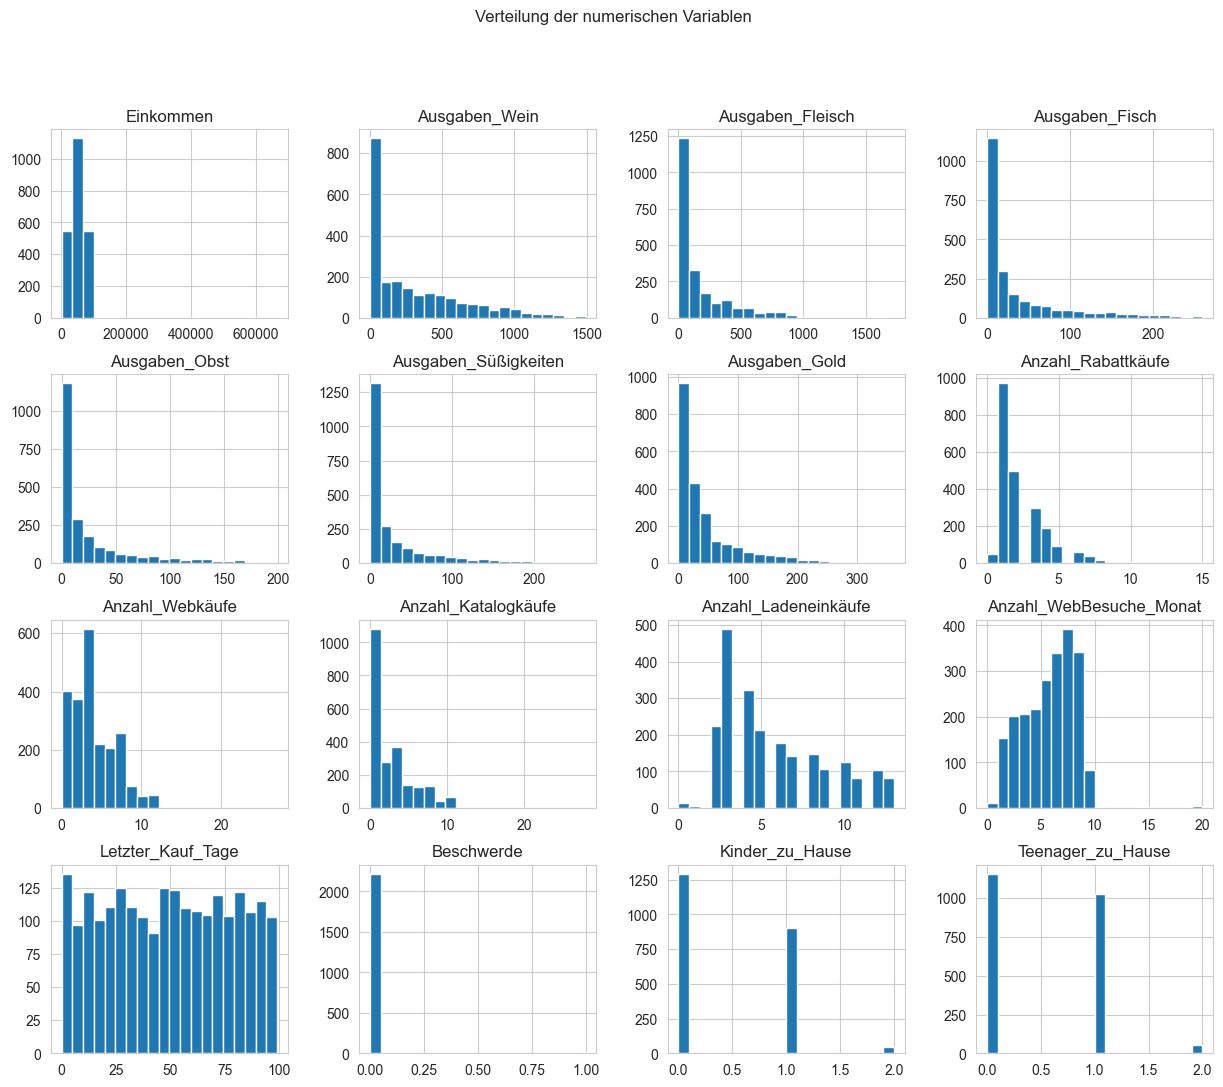

In [105]:
# 1.) Visualisierung der Verteilung von allen Variablen 

# Numerische Variablen (Verteilung)

num_features = [
    "Einkommen", "Ausgaben_Wein", "Ausgaben_Fleisch", "Ausgaben_Fisch",
    "Ausgaben_Obst", "Ausgaben_Süßigkeiten", "Ausgaben_Gold",
    "Anzahl_Rabattkäufe", "Anzahl_Webkäufe", "Anzahl_Katalogkäufe",
    "Anzahl_Ladeneinkäufe", "Anzahl_WebBesuche_Monat", "Letzter_Kauf_Tage",
    "Beschwerde", "Kinder_zu_Hause", "Teenager_zu_Hause"
]

df[num_features].hist(figsize=(15,12), bins=20)
plt.suptitle("Verteilung der numerischen Variablen")
plt.show()

Verteilung der letzte_Kampagne :
Antwort_Letzte_Kampagne
0    0.850893
1    0.149107
Name: proportion, dtype: float64



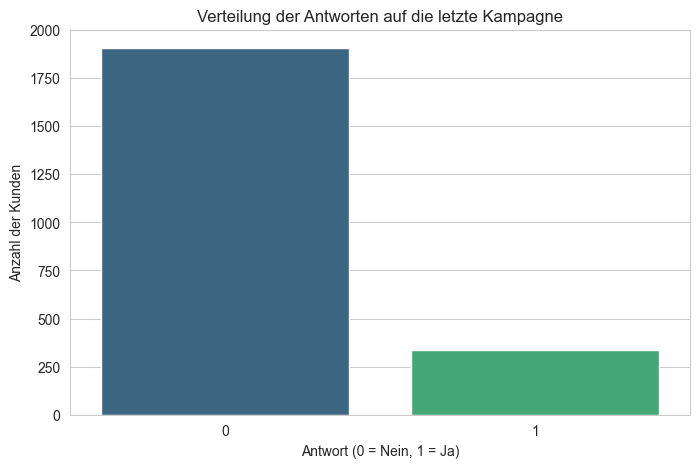

In [106]:
# Verteilung der Antworten auf die letzte Kampagne visualisieren
print("Verteilung der letzte_Kampagne :")
print(df["Antwort_Letzte_Kampagne"].value_counts(normalize=True)) 

print()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Antwort_Letzte_Kampagne', palette='viridis')
plt.title('Verteilung der Antworten auf die letzte Kampagne')
plt.xlabel('Antwort (0 = Nein, 1 = Ja)')
plt.ylabel('Anzahl der Kunden')
plt.show()

In [107]:
# Kommentar:

# Viele numerische Variablen sind rechtsschief verteilt (z.B. Einkommen, Alter);
# Einige Variablen haben Ausreißer (z.B. Einkommen, Alter);
# Die meisten Kunden haben keine Antwort auf die letzte_Kampagne gegeben (Antwort_Letzte_Kampagne = 0).

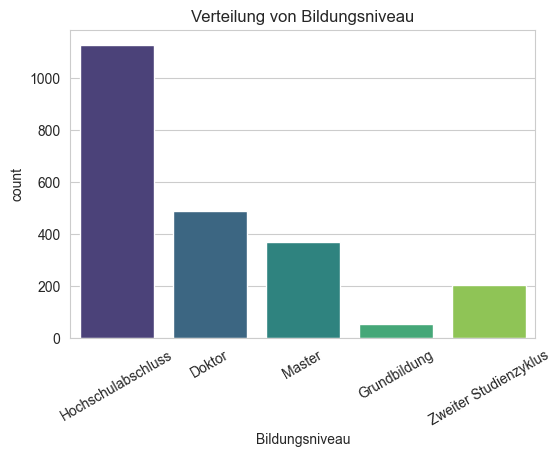

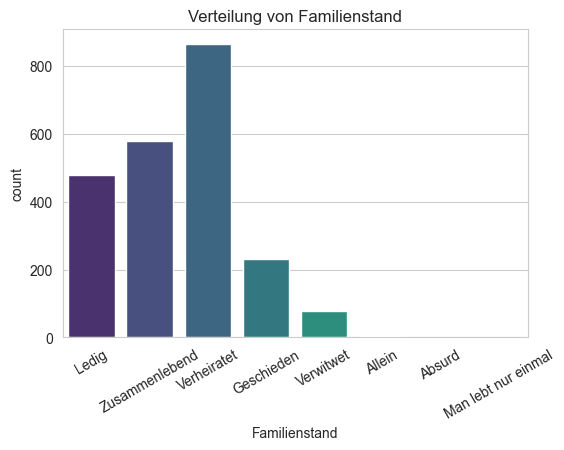

In [108]:
# 2.) Kategorische Variablen (Verteilung)

cat_features = ["Bildungsniveau", "Familienstand"]

for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette="viridis")
    plt.title(f"Verteilung von {col}")
    plt.xticks(rotation=30)
    plt.show()


In [109]:
# Kommentare:

# Bildungsniveau: Die meisten Kunden haben einen Hochschulabschluss oder eine Weiterbildung;
# Familienstand: Die meisten Kunden sind verheiratet oder ledig;
# Beschwerde: Die meisten Kunden haben keine Beschwerden eingereicht;
# Kinder_zu_Hause: Die meisten Kunden haben keine Kinder zu Hause;
# Teenager_zu_Hause: Die meisten Kunden haben keine Teenager zu Hause.

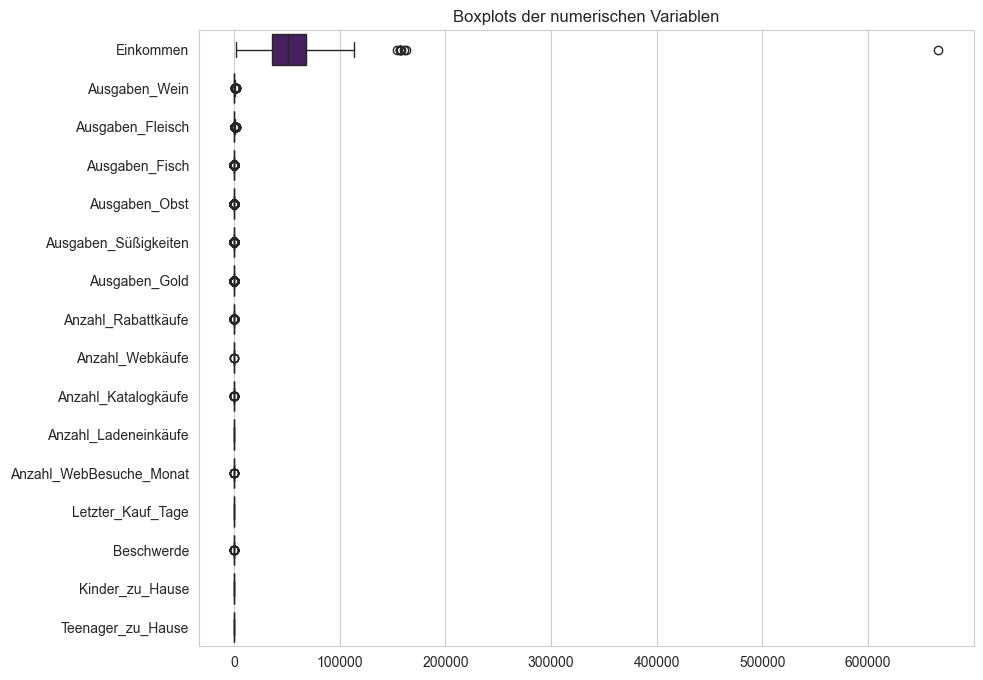

In [110]:
# 3.) Boxplots erstellen, um Ausreißer in den numerischen Variablen  zu identifizieren.

plt.figure(figsize=(10,8))
sns.boxplot(data=df[num_features], orient='h', palette='viridis')
plt.title('Boxplots der numerischen Variablen')
plt.show()

In [111]:
# Interpretation 

# Viele Ausreißer bei (Einkommen, Alter, Ausgaben_Fleisch, Ausgaben_Fisch...);
# Beschwerde, Kampagnen_Akzeptanz_Gesamt sind binär(0/1).

In [112]:
# 4.) Ausreißerbehandlung
# Spalten mit Ausreißern identifizieren

# Funktion zur Erkennung von Ausreißern
def detect_outliers_iqr(series, k=1.5):
    Q1 = series.quantile(0.25)     # Q1 ==> 25 Perzentil
    Q3 = series.quantile(0.75)     # Q3 ==> 75 Perzentil
    IQR = Q3 - Q1                  # IQR ==> Interquartilsabstand
    lower_bound = Q1 - k * IQR     
    upper_bound = Q3 + k * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers) > 0                           # True, wenn Ausreißer existieren

# Nur numerische Spalten prüfen
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_columns = []
for col in numeric_cols:
    if detect_outliers_iqr(df[col]):
        outlier_columns.append(col)

print("Spalten mit Ausreißern:")
print(outlier_columns)

Spalten mit Ausreißern:
['Geburtsjahr', 'Einkommen', 'Beschwerde', 'Ausgaben_Wein', 'Ausgaben_Obst', 'Ausgaben_Fleisch', 'Ausgaben_Fisch', 'Ausgaben_Süßigkeiten', 'Ausgaben_Gold', 'Anzahl_Rabattkäufe', 'Anzahl_Webkäufe', 'Anzahl_Katalogkäufe', 'Anzahl_WebBesuche_Monat', 'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert', 'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert', 'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne']


In [113]:
# Ausreißerprüfung mit plausiblen Grenzen

# Hilfsvariablen
current_year = 2024                # Platzhalter 

# Regeln für Ausreißer (plausible Grenzen)
rules = {                                              # Plausible Grenzen definieren
    "Geburtsjahr": (1920, 2005),
    "Einkommen": (0, 200000),
    "Ausgaben_Wein": (0, 10000),
    "Ausgaben_Obst": (0, 5000),
    "Ausgaben_Fleisch": (0, 10000),
    "Ausgaben_Fisch": (0, 5000),
    "Ausgaben_Süßigkeiten": (0, 5000),
    "Ausgaben_Gold": (0, 10000),
    "Ausgaben_pro_Kopf": (0, 20000),
    "Anzahl_Rabattkäufe": (0, 200),
    "Anzahl_Webkäufe": (0, 200),
    "Anzahl_Katalogkäufe": (0, 200),
    "Anzahl_WebBesuche_Monat": (0, 30),
    "Kampagne_1_Akzeptiert": (0, 1),
    "Kampagne_2_Akzeptiert": (0, 1),
    "Kampagne_3_Akzeptiert": (0, 1),
    "Kampagne_4_Akzeptiert": (0, 1),
    "Kampagne_5_Akzeptiert": (0, 1),
    "Antwort_Letzte_Kampagne": (0, 1),
    "Beschwerde": (0, 1)
}

# Funktion: prüft Ausreißer
def check_outliers(df, rules):
    outlier_report = {}
    for col, (low, high) in rules.items():
        if col in df.columns:
            mask = (df[col] < low) | (df[col] > high)
            outliers = df[mask]
            if not outliers.empty:
                outlier_report[col] = outliers[[col]].head(10)  # nur erste 10 zeigen
    return outlier_report

# Ausreißerprüfung starten
outliers = check_outliers(df, rules)

# Ergebnisse ausgeben
for col, vals in outliers.items():
    print(f"\n Ausreißer in {col}:")
    print(vals.to_string(index=False))



 Ausreißer in Geburtsjahr:
 Geburtsjahr
        2006
        1910
        1903
        1909
        2006

 Ausreißer in Einkommen:
 Einkommen
  666666.0


In [114]:
# Ausreißerbehandlung 
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)], lower_bound, upper_bound

# Ausreißer prüfen
outliers_birth_year, lb_birth_year, ub_birth_year = detect_outliers_iqr(df["Geburtsjahr"])
outliers_income, lb_inc, ub_inc = detect_outliers_iqr(df["Einkommen"])

print("---- GEBURTSJAHR ----")
print(f"Untere Grenze: {lb_birth_year:.2f}, Obere Grenze: {ub_birth_year:.2f}")
print(f"Anzahl Ausreißer: {len(outliers_birth_year)}")
print(outliers_birth_year.sort_values().head())

print("\n---- EINKOMMEN ----")
print(f"Untere Grenze: {lb_inc:.2f}, Obere Grenze: {ub_inc:.2f}")
print(f"Anzahl Ausreißer: {len(outliers_income)}")
print(outliers_income.sort_values().tail())


---- GEBURTSJAHR ----
Untere Grenze: 1942.00, Obere Grenze: 2014.00
Anzahl Ausreißer: 3
239    1903
339    1909
192    1910
Name: Geburtsjahr, dtype: int64

---- EINKOMMEN ----
Untere Grenze: -13587.75, Obere Grenze: 117416.25
Anzahl Ausreißer: 8
164     157243.0
1300    157733.0
687     160803.0
617     162397.0
2233    666666.0
Name: Einkommen, dtype: float64


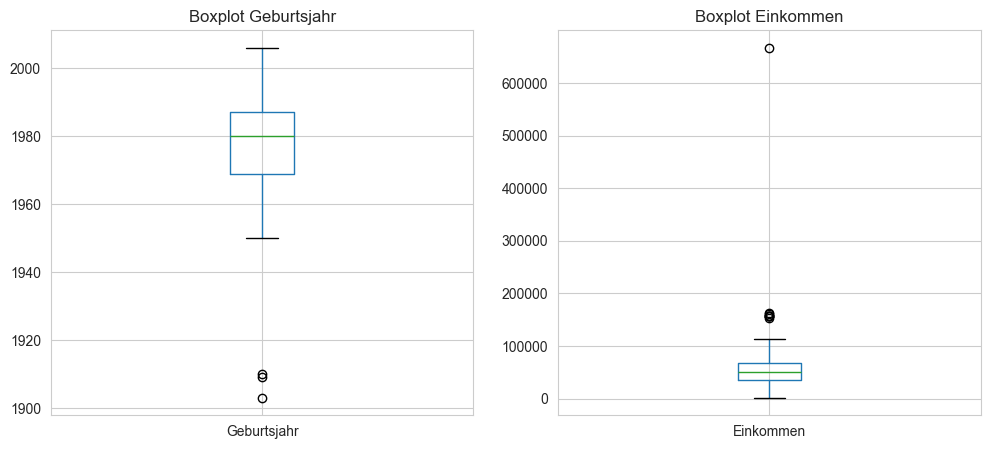

In [115]:
# Boxplots zur Visualisierung der Ausreißer
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df.boxplot(column="Geburtsjahr")
plt.title("Boxplot Geburtsjahr")

plt.subplot(1,2,2)
df.boxplot(column="Einkommen")
plt.title("Boxplot Einkommen")

plt.show()


In [116]:
# Kommentare:

''' Ausreißer bei Einkommen sind kein Fehler, Hohe Einkommen = wahrscheinliche „Luxuskunden“'''

' Ausreißer bei Einkommen sind kein Fehler, Hohe Einkommen = wahrscheinliche „Luxuskunden“'

In [117]:
# Ausreißer behandeln

df["Alter"] = 2024 - df["Geburtsjahr"]

# 1. Letzter_Kauf_Tage prüfen (z. B. > 3650 Tage = 10 Jahre entfernen)
df = df[df["Letzter_Kauf_Tage"] < 3650]

# 2. Log-Transformation für Ausgaben & Einkommen
cols_log = ["Einkommen", "Ausgaben_Wein", "Ausgaben_Fleisch",
            "Ausgaben_Fisch", "Ausgaben_Obst", "Ausgaben_Süßigkeiten", "Ausgaben_Gold"]

for col in cols_log:
    df[col] = np.log1p(df[col])   # log(1+x), robust auch für Nullen

# 3. Robust Scaling (optional für Modelle, die empfindlich auf Skalen sind)
scaler = RobustScaler()
df[cols_log] = scaler.fit_transform(df[cols_log])

# Ergebnis prüfen
print("Daten nach Bereinigung und Transformation:")
print(df[cols_log + ["Letzter_Kauf_Tage", "Beschwerde"]].describe())



Daten nach Bereinigung und Transformation:
         Einkommen  Ausgaben_Wein  Ausgaben_Fleisch  Ausgaben_Fisch  \
count  2240.000000    2240.000000       2240.000000     2240.000000   
mean     -0.141213      -0.161942         -0.035445       -0.011836   
std       0.770479       0.598112          0.596362        0.651072   
min      -5.191366      -1.711295         -1.611837       -1.007628   
25%      -0.564436      -0.647547         -0.529560       -0.463029   
50%       0.000000       0.000000          0.000000        0.000000   
75%       0.435564       0.352453          0.470440        0.536971   
max       3.924215       0.711876          1.235397        1.176859   

       Ausgaben_Obst  Ausgaben_Süßigkeiten  Ausgaben_Gold  Letzter_Kauf_Tage  \
count    2240.000000           2240.000000    2240.000000        2240.000000   
mean        0.014733              0.014972      -0.056157          49.109375   
std         0.554293              0.562670       0.740159          28.962453 

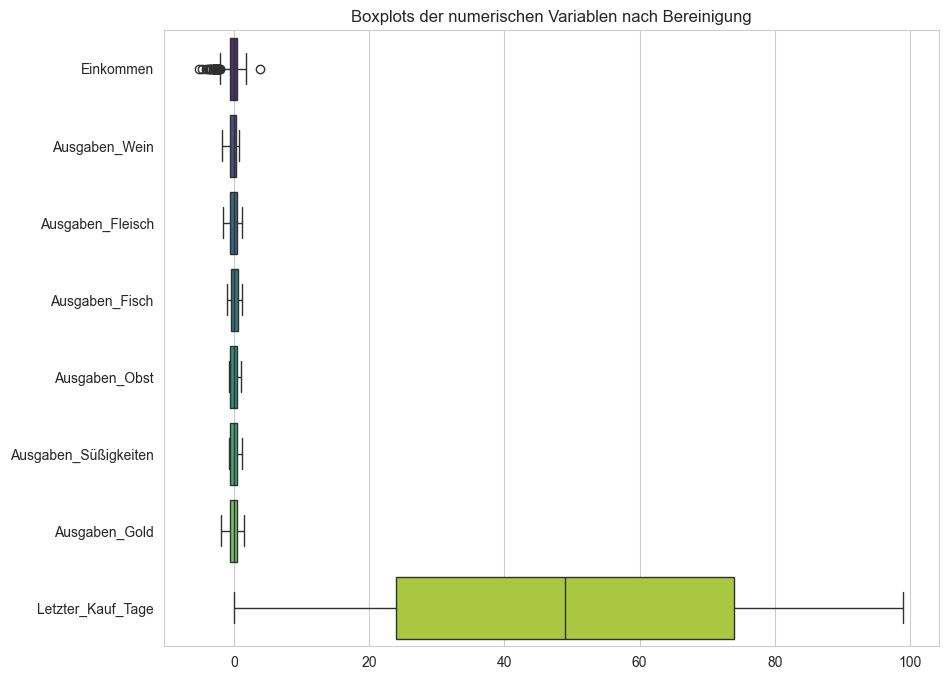

In [118]:
# Boxplots nach Bereinigung
plt.figure(figsize=(10,8))
sns.boxplot(data=df[cols_log + ["Letzter_Kauf_Tage"]], orient='h', palette='viridis')
plt.title('Boxplots der numerischen Variablen nach Bereinigung')
plt.show()

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Geburtsjahr              2240 non-null   int64  
 2   Bildungsniveau           2240 non-null   object 
 3   Familienstand            2240 non-null   object 
 4   Einkommen                2240 non-null   float64
 5   Kinder_zu_Hause          2240 non-null   int64  
 6   Teenager_zu_Hause        2240 non-null   int64  
 7   Datum_Kunde              2240 non-null   object 
 8   Letzter_Kauf_Tage        2240 non-null   int64  
 9   Beschwerde               2240 non-null   int64  
 10  Ausgaben_Wein            2240 non-null   float64
 11  Ausgaben_Obst            2240 non-null   float64
 12  Ausgaben_Fleisch         2240 non-null   float64
 13  Ausgaben_Fisch           2240 non-null   float64
 14  Ausgaben_Süßigkeiten    

In [120]:
# Fehlende Werte nach Ausreißerbehandlung prüfen und behandeln

# Fehlende Werte prüfen
print("Fehlende Werte nach Ausreißerbehandlung:")
print(df.isnull().sum())

Fehlende Werte nach Ausreißerbehandlung:
ID                         0
Geburtsjahr                0
Bildungsniveau             0
Familienstand              0
Einkommen                  0
Kinder_zu_Hause            0
Teenager_zu_Hause          0
Datum_Kunde                0
Letzter_Kauf_Tage          0
Beschwerde                 0
Ausgaben_Wein              0
Ausgaben_Obst              0
Ausgaben_Fleisch           0
Ausgaben_Fisch             0
Ausgaben_Süßigkeiten       0
Ausgaben_Gold              0
Anzahl_Rabattkäufe         0
Anzahl_Webkäufe            0
Anzahl_Katalogkäufe        0
Anzahl_Ladeneinkäufe       0
Anzahl_WebBesuche_Monat    0
Kampagne_1_Akzeptiert      0
Kampagne_2_Akzeptiert      0
Kampagne_3_Akzeptiert      0
Kampagne_4_Akzeptiert      0
Kampagne_5_Akzeptiert      0
Antwort_Letzte_Kampagne    0
Alter                      0
dtype: int64


In [121]:
# Fehlende Werte behandeln 
# Numerische Spalten mit Median füllen
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Kategorische Spalten mit 'Unbekannt' füllen
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna("Unbekannt", inplace=True)

# Kontrolle
print(df.isna().sum())


ID                         0
Geburtsjahr                0
Bildungsniveau             0
Familienstand              0
Einkommen                  0
Kinder_zu_Hause            0
Teenager_zu_Hause          0
Datum_Kunde                0
Letzter_Kauf_Tage          0
Beschwerde                 0
Ausgaben_Wein              0
Ausgaben_Obst              0
Ausgaben_Fleisch           0
Ausgaben_Fisch             0
Ausgaben_Süßigkeiten       0
Ausgaben_Gold              0
Anzahl_Rabattkäufe         0
Anzahl_Webkäufe            0
Anzahl_Katalogkäufe        0
Anzahl_Ladeneinkäufe       0
Anzahl_WebBesuche_Monat    0
Kampagne_1_Akzeptiert      0
Kampagne_2_Akzeptiert      0
Kampagne_3_Akzeptiert      0
Kampagne_4_Akzeptiert      0
Kampagne_5_Akzeptiert      0
Antwort_Letzte_Kampagne    0
Alter                      0
dtype: int64


In [122]:
# # Zusammenhang zwischen Einkommen und Ausgaben
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=df, x='Einkommen', y='Ausgaben_Gold', hue='Antwort_Letzte_Kampagne', palette='viridis')
# plt.title('Einkommen vs. Ausgaben für Gold')
# plt.xlabel('Einkommen')
# plt.ylabel('Ausgaben für Gold')
# plt.show()

4. **Korrelationsmatrix**

                         Einkommen  Ausgaben_Wein  Ausgaben_Fleisch  \
Einkommen                 1.000000       0.782766          0.717080   
Ausgaben_Wein             0.782766       1.000000          0.826410   
Ausgaben_Fleisch          0.717080       0.826410          1.000000   
Ausgaben_Fisch            0.457294       0.495690          0.704935   
Ausgaben_Obst             0.473079       0.502767          0.704529   
Ausgaben_Süßigkeiten      0.459333       0.490236          0.685692   
Ausgaben_Gold             0.407327       0.556717          0.608013   
Anzahl_Rabattkäufe       -0.084411       0.138672          0.049040   
Anzahl_Webkäufe           0.445106       0.653687          0.562289   
Anzahl_Katalogkäufe       0.584487       0.637068          0.745622   
Anzahl_Ladeneinkäufe      0.614984       0.732699          0.708257   
Anzahl_WebBesuche_Monat  -0.598853      -0.389183         -0.501309   
Letzter_Kauf_Tage         0.006493       0.015577          0.029396   
Beschw

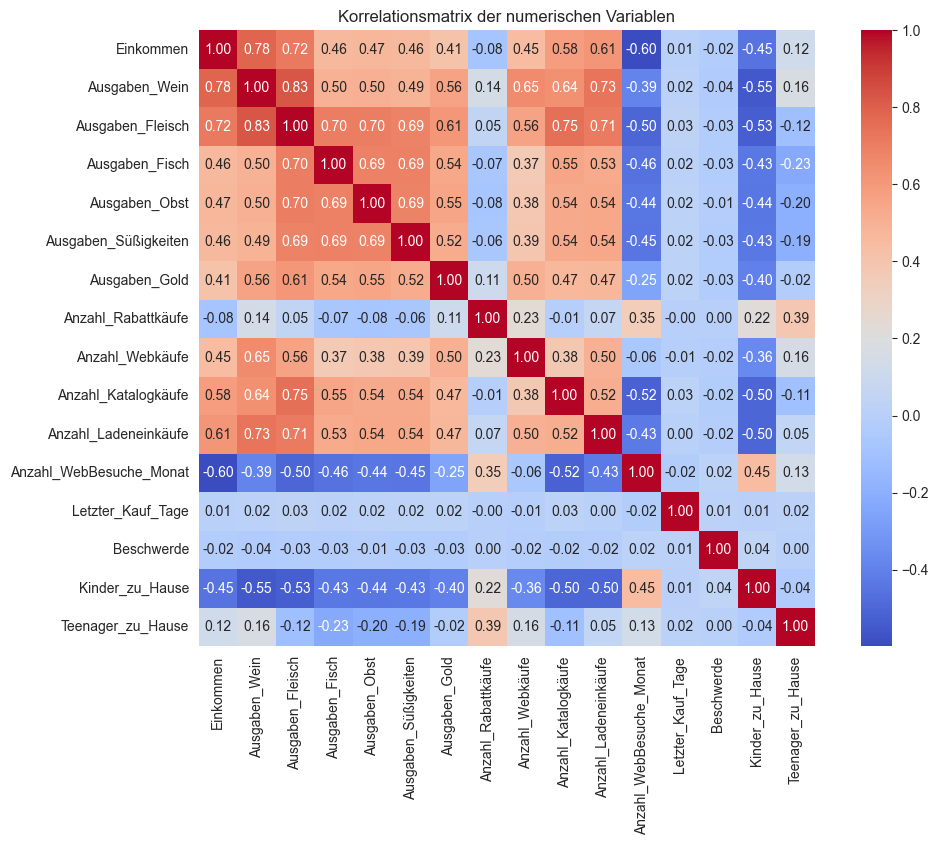

In [123]:
# 1.) Korrelationsmatrix numerischen Variablen berechnen und visualisieren

# Berechnung der Korrelationsmatrix
corr_matrix_num = df[num_features].corr()
print(corr_matrix_num)

# Visualisierung der Korrelationsmatrix als Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix_num, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korrelationsmatrix der numerischen Variablen")
plt.show()

In [124]:
# Korrelation zwischen Zielvariable und numerischen Features (Korrelationskoeffizient)
corr_target = df[num_features + ['Antwort_Letzte_Kampagne']].corr()['Antwort_Letzte_Kampagne'].sort_values(ascending=False)
print("Korrelation mit Zielvariable:")
print(corr_target)

Korrelation mit Zielvariable:
Antwort_Letzte_Kampagne    1.000000
Ausgaben_Fleisch           0.222175
Anzahl_Katalogkäufe        0.220810
Ausgaben_Wein              0.174410
Ausgaben_Gold              0.173765
Anzahl_Webkäufe            0.148730
Ausgaben_Obst              0.148634
Ausgaben_Süßigkeiten       0.135565
Einkommen                  0.126492
Ausgaben_Fisch             0.112779
Anzahl_Ladeneinkäufe       0.039363
Anzahl_Rabattkäufe         0.002238
Beschwerde                -0.001707
Anzahl_WebBesuche_Monat   -0.003987
Kinder_zu_Hause           -0.080008
Teenager_zu_Hause         -0.154446
Letzter_Kauf_Tage         -0.198437
Name: Antwort_Letzte_Kampagne, dtype: float64


In [125]:
# Mittelwert der Zielvariable pro Kategorie
print(df.groupby('Bildungsniveau')['Antwort_Letzte_Kampagne'].mean().sort_values(ascending=False))
print()
print(df.groupby('Familienstand')['Antwort_Letzte_Kampagne'].mean().sort_values(ascending=False))

Bildungsniveau
Doktor                   0.207819
Master                   0.154054
Hochschulabschluss       0.134871
Zweiter Studienzyklus    0.108374
Grundbildung             0.037037
Name: Antwort_Letzte_Kampagne, dtype: float64

Familienstand
Absurd                 0.500000
Man lebt nur einmal    0.500000
Allein                 0.333333
Verwitwet              0.246753
Ledig                  0.220833
Geschieden             0.206897
Verheiratet            0.113426
Zusammenlebend         0.103448
Name: Antwort_Letzte_Kampagne, dtype: float64


In [126]:
# Zielgruppen-Vergleich ('Antwort_Letzte_Kampagne')

vergleich = df.groupby("Antwort_Letzte_Kampagne")[num_features].mean().T
print("Durchschnittswerte pro Gruppe:")
print(vergleich)

Durchschnittswerte pro Gruppe:
Antwort_Letzte_Kampagne          0          1
Einkommen                -0.182002   0.091551
Ausgaben_Wein            -0.205600   0.087200
Ausgaben_Fleisch         -0.090897   0.280999
Ausgaben_Fisch           -0.042567   0.163531
Ausgaben_Obst            -0.019748   0.211498
Ausgaben_Süßigkeiten     -0.016952   0.197148
Ausgaben_Gold            -0.109984   0.251013
Anzahl_Rabattkäufe        2.323190   2.335329
Anzahl_Webkäufe           3.911857   5.071856
Anzahl_Katalogkäufe       2.391920   4.203593
Anzahl_Ladeneinkäufe      5.736621   6.095808
Anzahl_WebBesuche_Monat   5.320567   5.293413
Letzter_Kauf_Tage        51.514690  35.383234
Beschwerde                0.009444   0.008982
Kinder_zu_Hause           0.462225   0.341317
Teenager_zu_Hause         0.541448   0.305389


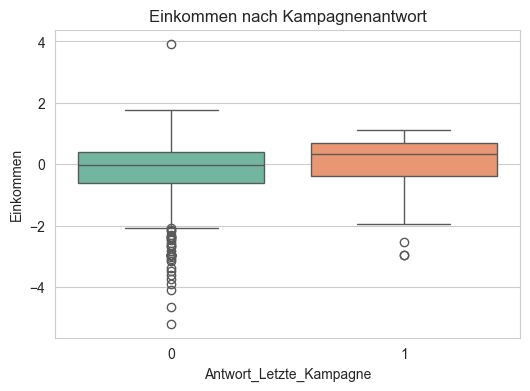

In [127]:
# Boxplot Beispiel: Einkommen nach Kampagnenantwort
plt.figure(figsize=(6,4))
sns.boxplot(x="Antwort_Letzte_Kampagne", y="Einkommen", data=df, palette="Set2")
plt.title("Einkommen nach Kampagnenantwort")
plt.show()

In [128]:
# Kommetare:

''' Kunden, die auf die Kampagne reagieren, sind kaufkräftiger, aktiver und geben mehr Geld aus. Sie kaufen häufiger und haben kürzere Intervalle seit dem letzten Kauf.
Diese Gruppe ist besonders interessant für gezielte Marketingmaßnahmen!'''

# 

' Kunden, die auf die Kampagne reagieren, sind kaufkräftiger, aktiver und geben mehr Geld aus. Sie kaufen häufiger und haben kürzere Intervalle seit dem letzten Kauf.\nDiese Gruppe ist besonders interessant für gezielte Marketingmaßnahmen!'

## Aufgabe 2: Datenvorverarbeitung 

1. **Feature Engeneering**

In [129]:
# 1.) Neue Spalte erstellen

# 'Gesamtausgabe' (Summe aller Ausgaben-Spalten)
df['Gesamtausgabe'] = (
    df['Ausgaben_Wein'] +
    df['Ausgaben_Obst'] +
    df['Ausgaben_Fleisch'] +
    df['Ausgaben_Fisch'] +
    df['Ausgaben_Süßigkeiten'] +
    df['Ausgaben_Gold']
)

In [130]:
# Alter aus Geburtsjahr berechnen
aktuelles_jahr = 2024
df['Alter'] = aktuelles_jahr - df['Geburtsjahr']

df[['Geburtsjahr', 'Alter']].head()

,Geburtsjahr,Alter
0,1967,57
1,1964,60
2,1975,49
3,1994,30
4,1991,33


In [131]:
# Familiengröße berechnen (Kinder + Teenager) 
df['Familiengröße'] = df['Kinder_zu_Hause'] + df['Teenager_zu_Hause']
df['Familiengröße'].value_counts()

Familiengröße
1    1128
0     638
2     421
3      53
Name: count, dtype: int64

In [132]:
# Kampagnen akzeptanz gesamt
kampagnen = ['Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert', 'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert', 'Kampagne_5_Akzeptiert']
df['Kampagnen_Akzeptanz_Gesamt'] = df[kampagnen].sum(axis=1)

In [133]:
# Ausgaben pro Kopf:
df['Ausgaben_pro_Kopf'] = df['Gesamtausgabe'] / df['Familiengröße'].replace(0, np.nan)
df['Ausgaben_pro_Kopf'].fillna(df['Gesamtausgabe'], inplace=True)                        # Wenn Familiengröße 0 ist, setze Ausgaben_pro_Kopf = Gesamtausgabe

In [134]:
# Kundenbindungsdauer aus Datum_Kunde berechnen (in Tagen)
df["Datum_Kunde"] = pd.to_datetime(df["Datum_Kunde"], dayfirst=True, errors="coerce")    
df['Kundenbindungsdauer'] = (pd.to_datetime('2025-01-01') - df['Datum_Kunde']).dt.days      # Kundenbindungsdauer ist die Differenz zwischen dem 01.01.2025 und dem Datum_Kunde

# Beispiel: Durchschnittliche Kundenbindungsdauer pro Gruppe
print(df.groupby("Antwort_Letzte_Kampagne")['Kundenbindungsdauer'].mean().T)
df['Kundenbindungsdauer'].value_counts()

Antwort_Letzte_Kampagne
0    523.941238
1    634.380240
Name: Kundenbindungsdauer, dtype: float64


Kundenbindungsdauer
854    12
234    11
687    11
842    11
224    10
       ..
427     1
510     1
813     1
743     1
358     1
Name: count, Length: 663, dtype: int64

In [135]:
# Spalte Familienstand bereinigen
print(df['Familienstand'].unique())

# Liste der erlaubten Werte (z.B. nach Sichtung)
erlaubte_werte = ['Verheiratet', 'Ledig', 'Geschieden', 'Witwe', 'Zusammenlebend']

# Zeilen mit komischen Werten entfernen
df = df[df['Familienstand'].isin(erlaubte_werte)]

# Kontrolle
df['Familienstand'].nunique()

['Ledig' 'Zusammenlebend' 'Verheiratet' 'Geschieden' 'Verwitwet' 'Allein'
 'Absurd' 'Man lebt nur einmal']


4

In [136]:
# Einkommens- und Ausgaben-Schwellen (Luxus = oberes 5%)
income_threshold = df["Einkommen"].quantile(0.95)
spend_threshold = df["Gesamtausgabe"].quantile(0.95)

# Kunden kategorisieren
df["Kundentyp"] = "Normal"
df.loc[(df["Einkommen"] > income_threshold) & (df["Gesamtausgabe"] > spend_threshold), "Kundentyp"] = "Luxuskunde"
df.loc[(df["Einkommen"] > income_threshold) & (df["Gesamtausgabe"] <= spend_threshold), "Kundentyp"] = "Verdächtig (hohes Einkommen, niedrige Ausgaben)"
df.loc[(df["Einkommen"] <= income_threshold) & (df["Gesamtausgabe"] > spend_threshold), "Kundentyp"] = "Verdächtig (niedriges Einkommen, hohe Ausgaben)"

# Ergebnisse anzeigen
print(df["Kundentyp"].value_counts())

# Beispiel: Liste der Luxuskunden anzeigen
luxus = df[df["Kundentyp"] == "Luxuskunde"]
print("\nBeispiel Luxuskunden:")
print(luxus[["Einkommen", "Gesamtausgabe"]].head())

Kundentyp
Normal                                             1967
Verdächtig (niedriges Einkommen, hohe Ausgaben)      82
Verdächtig (hohes Einkommen, niedrige Ausgaben)      81
Luxuskunde                                           26
Name: count, dtype: int64

Beispiel Luxuskunden:
     Einkommen  Gesamtausgabe
102   0.783138       4.545129
347   0.767731       4.721983
418   0.876232       4.466464
426   0.906942       4.356486
456   0.850922       4.495561


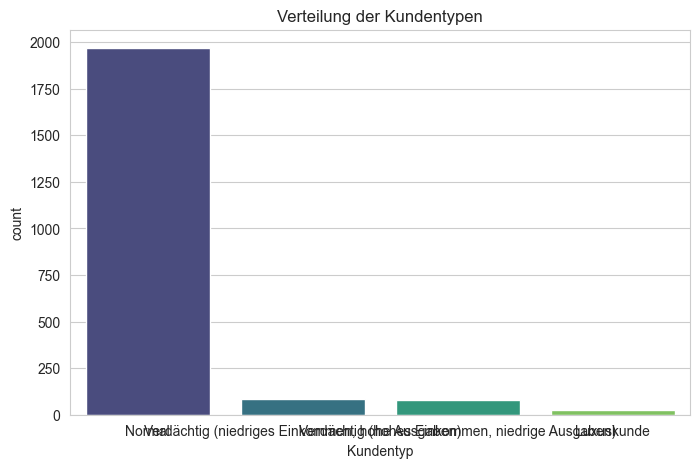

In [137]:
# Kundentyp visualisieren

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Kundentyp', palette='viridis', order=df['Kundentyp'].value_counts().index)
plt.title('Verteilung der Kundentypen')
plt.show()


In [138]:
# Beispiel: Durchschnittliches Einkommen pro Gruppe
print(df.groupby("Antwort_Letzte_Kampagne")['Einkommen'].mean().T)



Antwort_Letzte_Kampagne
0   -0.188833
1    0.085804
Name: Einkommen, dtype: float64


In [139]:
# Beispiel: Durchschnittliche Ausgaben pro Gruppe
print(df.groupby("Antwort_Letzte_Kampagne")['Gesamtausgabe'].mean().T)

Antwort_Letzte_Kampagne
0   -0.511635
1    1.195967
Name: Gesamtausgabe, dtype: float64


In [140]:
# Beispiel: Durchschnittliche Familiegröße pro Gruppe
print(df.groupby("Antwort_Letzte_Kampagne")['Alter'].mean().T)

Antwort_Letzte_Kampagne
0    45.002711
1    43.903846
Name: Alter, dtype: float64


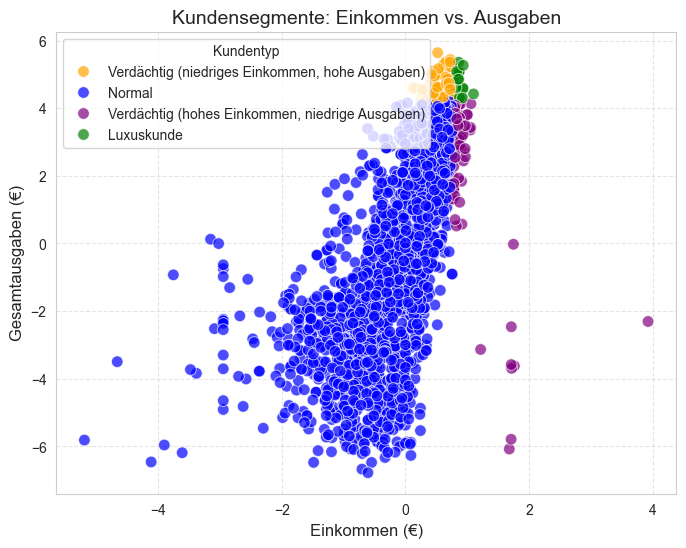

In [141]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Einkommen",
    y="Gesamtausgabe",
    hue="Kundentyp",
    palette={
        "Normal": "blue",
        "Verdächtig (niedriges Einkommen, hohe Ausgaben)": "orange",
        "Verdächtig (hohes Einkommen, niedrige Ausgaben)": "purple",
        "Luxuskunde": "green"
    },
    alpha=0.7,
    s=70
)

plt.title("Kundensegmente: Einkommen vs. Ausgaben", fontsize=14)
plt.xlabel("Einkommen (€)", fontsize=12)
plt.ylabel("Gesamtausgaben (€)", fontsize=12)
plt.legend(title="Kundentyp")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig("Kundensegmente.png", dpi=150, bbox_inches="tight")
plt.show()

2. **Variable vorverarbeiten**

In [142]:
# 1.) Encoding und Skalierung

# Kategorische Variablen umwandeln (OneHotEncoder)
for col in ['Bildungsniveau', 'Familienstand']:
    le = LabelEncoder()
    df[col + '_LE'] = le.fit_transform(df[col])

# Skalierung der numerischen Variablen
num_features = [
    "Alter", "Einkommen", "Kinder_zu_Hause", "Teenager_zu_Hause","Kundenbindungsdauer", 
    "Beschwerde", "Ausgaben_Wein", "Ausgaben_Fleisch", "Ausgaben_Fisch",
    "Ausgaben_Obst", "Ausgaben_Süßigkeiten", "Ausgaben_Gold",
    "Anzahl_Rabattkäufe", "Anzahl_Webkäufe", "Anzahl_Katalogkäufe",
    "Anzahl_Ladeneinkäufe", "Anzahl_WebBesuche_Monat", "Letzter_Kauf_Tage",
    'Kampagnen_Akzeptanz_Gesamt', 'Ausgaben_pro_Kopf', 'Gesamtausgabe'
]

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

In [143]:
# 2.) Variablen auswählen / Aufteilen in Features und Zielvariable

# Auswahl der Zielvariable und Features

# Zielvariable
y = df['Antwort_Letzte_Kampagne']

# Features (unabhängige Variablen)
feature = ['Alter', 'Einkommen', 'Kundenbindungsdauer', 
           'Gesamtausgabe', 'Ausgaben_pro_Kopf', 
           'Anzahl_Rabattkäufe', 'Anzahl_Webkäufe', 'Anzahl_Katalogkäufe',
           'Anzahl_Ladeneinkäufe', 'Anzahl_WebBesuche_Monat', 'Letzter_Kauf_Tage',
           'Kampagnen_Akzeptanz_Gesamt', 'Bildungsniveau_LE', 'Familienstand_LE']

X = df[feature]

# Aufteilen in Trainings- und Testdaten (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Trainingsdaten: {X_train.shape}, Testdaten: {X_test.shape}")

Trainingsdaten: (1724, 14), Testdaten: (432, 14)


In [144]:
# Kommentare:


In [145]:
# Kontrolle

X_train
#y

,Alter,Einkommen,Kundenbindungsdauer,Gesamtausgabe,Ausgaben_pro_Kopf,Anzahl_Rabattkäufe,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_WebBesuche_Monat,Letzter_Kauf_Tage,Kampagnen_Akzeptanz_Gesamt,Bildungsniveau_LE,Familienstand_LE
1431,-0.322992,-0.792497,-1.074428,-0.969577,-1.164025,-0.682303,-1.103109,-0.902545,-0.851705,0.275363,0.166611,-0.436566,4,0
1329,2.029898,0.844812,-0.638589,1.391937,1.454647,-0.682303,1.418569,0.123767,-0.236640,-0.548624,-1.593903,1.043366,0,3
117,-0.743151,-0.478685,0.703599,1.127434,1.161341,1.384498,1.778809,-0.560441,-0.236640,1.511343,0.857009,-0.436566,4,2
112,0.517326,0.405803,-1.733140,-0.605478,-0.760277,0.351097,1.418569,-0.560441,0.685957,0.275363,-0.765426,1.043366,3,3
2227,0.601357,0.428993,0.644166,0.059892,-0.022451,1.384498,-0.022390,-0.218337,0.685957,-0.136630,-0.351187,-0.436566,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
652,-0.407024,0.727042,1.649569,0.870764,0.876721,1.384498,1.778809,1.150079,1.916087,0.275363,0.477290,-0.436566,2,2
1760,0.433294,0.589890,-0.301804,1.112718,1.145022,0.351097,1.058329,-0.218337,0.685957,-0.548624,0.649890,-0.436566,4,2
1313,1.189580,0.930885,-0.584109,1.149050,1.185311,1.384498,-0.022390,1.492183,1.301022,-1.372611,-1.214184,-0.436566,4,3
1013,0.097167,-0.617954,1.505940,-0.858378,-1.040717,-0.682303,-0.382629,-0.902545,-0.851705,1.099350,-1.214184,-0.436566,3,3


## Aufgabe 3: Modellierung 

1. **Logistische Regression**

In [146]:
# 1.) Trainiere logistische Regression zur Vorhersage von 'Antwort_Letzte_Kampagne'.

# Features und Zielvariable für logistische Regression definieren

X_log = df[feature]
y_log = df['Antwort_Letzte_Kampagne']

# Trainings- und Testdaten aufteilen
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# Numerische Features skalieren
numeric_features_log = X_train_log.select_dtypes(include=['float64', 'int64']).columns
scaler_log = StandardScaler()

X_train_log[numeric_features_log] = scaler_log.fit_transform(X_train_log[numeric_features_log])
X_test_log[numeric_features_log] = scaler_log.transform(X_test_log[numeric_features_log])

# Logistische Regression trainieren (mit Klassengewicht um Imbalanced Problem zu lösen)
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(X_train_log, y_train_log)

# Vorhersage auf Testdaten
y_pred_log = logreg.predict(X_test_log)

Bewertungsmetriken logistische Regression:
Accuracy: 0.8194444444444444
Precision: 0.42201834862385323
Recall: 0.7540983606557377
F1-Score: 0.5411764705882353

Konfusionsmatrix:
[[308  63]
 [ 15  46]]


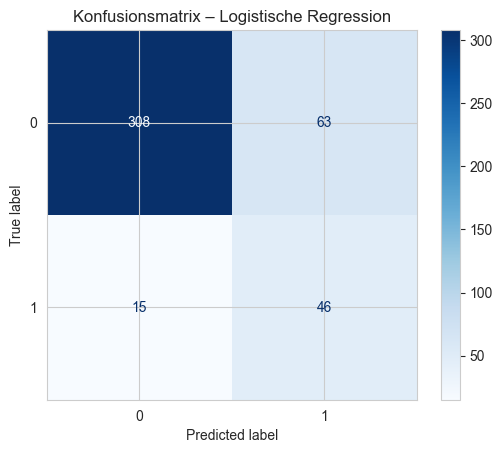

In [147]:
# 2.) Modellbewertung

# Ergebnisse ausgeben
print("Bewertungsmetriken logistische Regression:")
print("Accuracy:", accuracy_score(y_test_log, y_pred_log))
print("Precision:", precision_score(y_test_log, y_pred_log))
print("Recall:", recall_score(y_test_log, y_pred_log))
print("F1-Score:", f1_score(y_test_log, y_pred_log))

print()

# Konfusionsmatrix
cm = confusion_matrix(y_test_log, y_pred_log)
print("Konfusionsmatrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)

# Plot
disp.plot(cmap="Blues", values_format="d")
plt.title("Konfusionsmatrix – Logistische Regression")
plt.show()

In [148]:
logreg

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [149]:
# 1.) Modelierung mt Random Forest Classifier (mit Klassengewicht um Imbalanced Problem zu lösen)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random-Forest-Modell erstellen und trainieren

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Vorhersage auf Testdaten
y_pred_rf = rf.predict(X_test)

# Ergebnisse ausgeben
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²-Score:", r2_score(y_test, y_pred_rf))

print()

# Feature-Importance anzeigen
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print("Feature Importances:")
print(importances.sort_values(ascending=False))


MAE: 0.11574074074074074
MSE: 0.11574074074074074
R²-Score: 0.0708478513356563

Feature Importances:
Letzter_Kauf_Tage             0.135612
Kampagnen_Akzeptanz_Gesamt    0.119205
Kundenbindungsdauer           0.115548
Einkommen                     0.095790
Ausgaben_pro_Kopf             0.079556
Gesamtausgabe                 0.077123
Anzahl_Katalogkäufe           0.070173
Alter                         0.060540
Anzahl_Ladeneinkäufe          0.057149
Anzahl_WebBesuche_Monat       0.047731
Anzahl_Webkäufe               0.041692
Familienstand_LE              0.037828
Anzahl_Rabattkäufe            0.035840
Bildungsniveau_LE             0.026214
dtype: float64


In [150]:
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


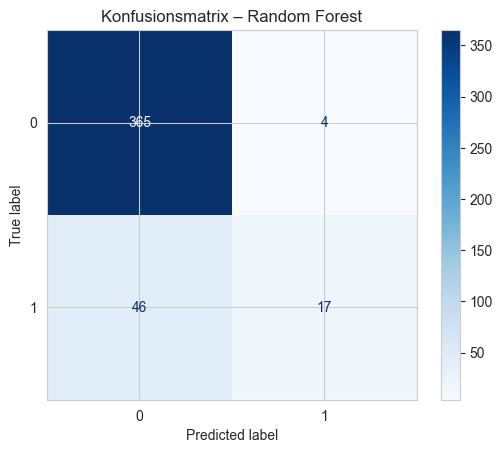

Konfusionsmatrix:
[[365   4]
 [ 46  17]]

Bewertungsmetriken Random Forest:
Accuracy:  0.884
Precision: 0.810
Recall:    0.270
F1-Score:  0.405


In [151]:
# Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)

# Plot
disp.plot(cmap="Blues", values_format="d")
plt.title("Konfusionsmatrix – Random Forest")
plt.show()

print("Konfusionsmatrix:")
print(cm)

# Kennzahlen berechnen

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print()

print("Bewertungsmetriken Random Forest:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

In [152]:
gesamtzahl = 365 + 4 + 46 +17
treffer = 365 + 17
fehler = 4 + 46
print(f"Trefferquote: {treffer/gesamtzahl:.3f}")
print(f"Fehlerquote: {fehler/gesamtzahl:.3f}")


Trefferquote: 0.884
Fehlerquote: 0.116


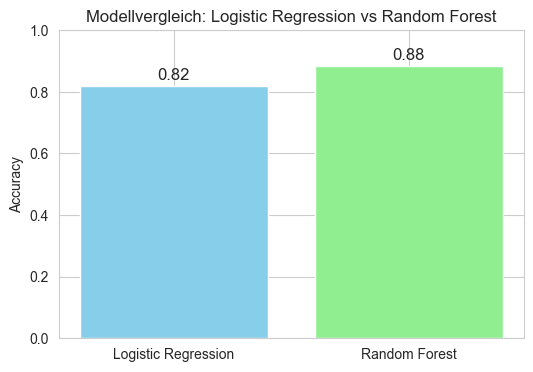

In [153]:
# Modellvergleich

# Balkendiagramm erstellen
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_log, accuracy_rf]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Modellvergleich: Logistic Regression vs Random Forest')

# Genauigkeitswerte oben auf die Balken schreiben
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)

plt.show()

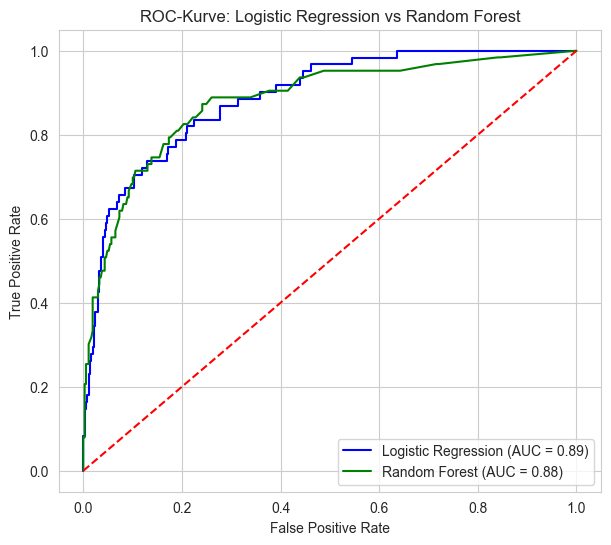

In [ ]:
# ROC-Kurve und AUC für beide Modelle berechnen und visualisieren

# Wahrscheinlichkeiten für die positive Klasse vorhersagen
y_prob_log = logreg.predict_proba(X_test_log)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ROC-Kurve und AUC für logistische Regression
fpr_log, tpr_log, _ = roc_curve(y_test_log, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

# ROC-Kurve und AUC für Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot der ROC-Kurven

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, color='blue', label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Zufallslinie
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve: Logistic Regression vs Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Aufgabe 4: Clustering mit PCA und K-Means

Anzahl Hauptkomponenten für mindestens 80% erklärte Varianz: 6


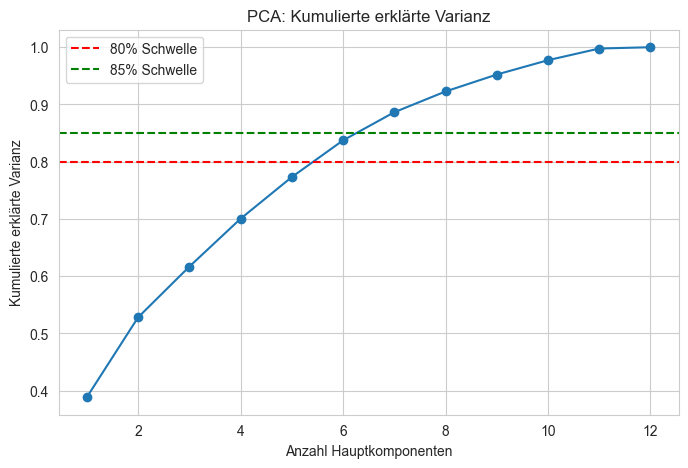

In [155]:
# 1. Numerische Features für Clustering auswählen (ohne Zielvariable und IDs)
cluster_features = [
    'Alter', 'Einkommen', 'Kundenbindungsdauer', 'Gesamtausgabe', 'Ausgaben_pro_Kopf',
    'Anzahl_Rabattkäufe', 'Anzahl_Webkäufe', 'Anzahl_Katalogkäufe',
    'Anzahl_Ladeneinkäufe', 'Anzahl_WebBesuche_Monat', 'Letzter_Kauf_Tage',
    'Kampagnen_Akzeptanz_Gesamt'
]

X_cluster = df[cluster_features]

# 2. Skalierung (falls noch nicht geschehen)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# 3. PCA anwenden
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_cluster_scaled)

# Kumulierte erklärte Varianz berechnen
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.80) + 1  # 80% Schwelle

print(f"Anzahl Hauptkomponenten für mindestens 80% erklärte Varianz: {n_components}")

# Visualisierung der kumulierten erklärten Varianz
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Schwelle')
plt.axhline(y=0.85, color='g', linestyle='--', label='85% Schwelle')
plt.xlabel('Anzahl Hauptkomponenten')
plt.ylabel('Kumulierte erklärte Varianz')
plt.title('PCA: Kumulierte erklärte Varianz')
plt.legend()
plt.grid(True)
plt.show()

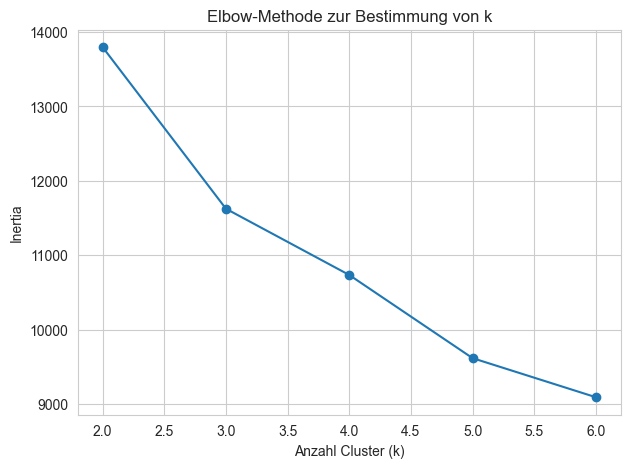

In [156]:
# 4. K-Means Clustering auf PCA-Komponenten
from sklearn.cluster import KMeans

# Elbow-Methode zur Bestimmung von k
inertia = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca[:, :n_components])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2, 7), inertia, marker='o')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow-Methode zur Bestimmung von k')
plt.grid(True)
plt.show()

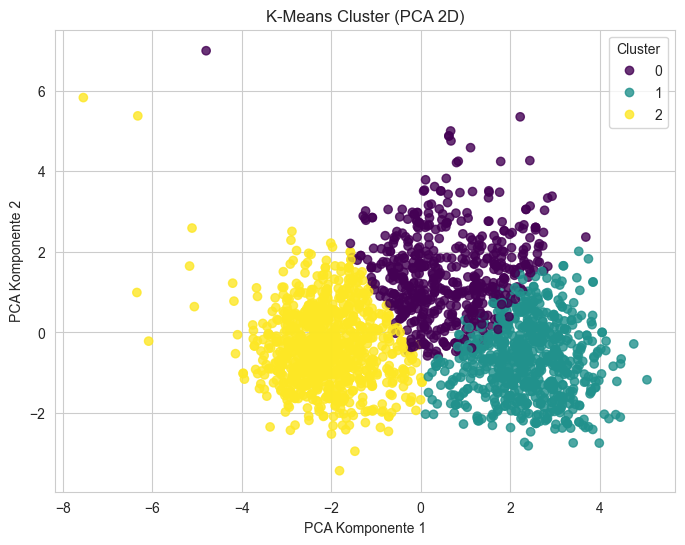

In [157]:
# Optimales k wählen (z.B. k=3)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans_final.fit_predict(X_pca[:, :n_components])

# Cluster-Zuordnung speichern
df['Cluster'] = clusters

# 5. Cluster visualisieren (erste 2 Hauptkomponenten)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.8)
plt.xlabel('PCA Komponente 1')
plt.ylabel('PCA Komponente 2')
plt.title('K-Means Cluster (PCA 2D)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True)
plt.show()


In [159]:
# 6. Cluster-Eigenschaften anzeigen
print(df.groupby('Cluster')[cluster_features].mean())

            Alter  Einkommen  Kundenbindungsdauer  Gesamtausgabe  \
Cluster                                                            
0        0.259451   0.226074             0.511557       0.309104   
1        0.094353   0.879950            -0.102758       1.030486   
2       -0.219555  -0.779971            -0.219788      -0.939035   

         Ausgaben_pro_Kopf  Anzahl_Rabattkäufe  Anzahl_Webkäufe  \
Cluster                                                           
0                 0.244523            1.044513         0.856113   
1                 1.047514           -0.499540         0.379799   
2                -0.914281           -0.234977        -0.774985   

         Anzahl_Katalogkäufe  Anzahl_Ladeneinkäufe  Anzahl_WebBesuche_Monat  \
Cluster                                                                       
0                   0.051276              0.352702                 0.483657   
1                   0.975790              0.843081                -0.989403   
2      